In [48]:
import torch
import torch_geometric.transforms as T
from torch.utils.data import random_split
from torch_geometric.datasets import MNISTSuperpixels

## Define sparsification and noise addtiontion as per GSAT paper

In [49]:
class AddGroundTruthMark(object):
    def __call__(self, data):
        # GSAT Definition: Nodes with nonzero pixel values are ground-truth explanations
        data.node_mask = (data.x[:, 0] > 0).float()
        return data
    
pre_transform = AddGroundTruthMark()

In [50]:
def paper_structural_graph(pos, img_size=28.0, sigma=0.1, threshold=0.1):
    """
    Computes the thresholded adjacency graph exactly as done in the DIR paper.
    """
    # 1. Scale coordinates (the paper divides by 28 so coords are roughly 0 to 1)
    coord = pos / img_size
    
    # 2. Compute pairwise Euclidean distances
    dist = torch.cdist(coord, coord)
    
    # 3. Apply Gaussian kernel to get adjacency weights
    A = torch.exp(-dist / (sigma * np.pi) ** 2)
    A.fill_diagonal_(0) # Remove self-loops
    
    # 4. === STRUCTURAL THRESHOLDING ===
    # Keep only edges where the weight is strictly greater than 0.1
    A = (A > threshold).float() * A
    
    # 5. Convert dense Adjacency matrix to sparse PyG edge_index
    # A.nonzero() returns [num_edges, 2], transpose it to PyG's [2, num_edges] format
    edge_index = A.nonzero(as_tuple=False).t().contiguous()
    
    # (Optional) Extract edge weights if your GNN uses them
    edge_attr = A[edge_index[0], edge_index[1]]
    
    return edge_index, edge_attr

In [51]:
import pickle
import torch
import numpy as np
from torch_geometric.data import Data
from pathlib import Path

def pure_pytorch_knn_graph(pos, k=8):
    """
    Computes a k-NN graph in pure PyTorch without requiring torch-cluster.
    """
    num_nodes = pos.size(0)
    
    # 1. Compute pairwise Euclidean distances between all nodes
    dist = torch.cdist(pos, pos)
    
    # 2. Prevent self-loops by setting the diagonal distance to infinity
    dist.fill_diagonal_(float('inf'))
    
    # 3. Find the indices of the 'k' closest nodes
    # col will have shape (num_nodes, k)
    _, col = torch.topk(dist, k=k, largest=False)
    
    # 4. Create the corresponding source nodes
    # row will have shape (num_nodes, k)
    row = torch.arange(num_nodes).view(-1, 1).expand(-1, k)
    
    # 5. Flatten and stack into PyG's [2, num_edges] format
    edge_index = torch.stack([row.flatten(), col.flatten()], dim=0)
    return edge_index



In [52]:
def convert_knyazev_pkl_to_pyg_fixed(pkl_path):
    print(f"Loading {pkl_path}...")
    with open(pkl_path, 'rb') as f:
        raw_data = pickle.load(f)
        
    pyg_data_list = []
    labels_array = raw_data[0]
    graphs_list = raw_data[1]
    
    for i in range(len(graphs_list)):
        intensity_raw = graphs_list[i][0]
        coord_raw = graphs_list[i][1]
        
        # 1. Node Features (Intensity)
        x = torch.tensor(intensity_raw, dtype=torch.float)
        if x.dim() == 1:
            x = x.unsqueeze(1) 
            
        # 2. Spatial Coordinates
        coord_tensor = torch.tensor(coord_raw, dtype=torch.float)
        pos = torch.stack([coord_tensor[:, 1], coord_tensor[:, 0]], dim=1)
        
        # 3. Generate Edges (REPLACED: Using paper's structural thresholding)
        # edge_index = pure_pytorch_knn_graph(pos, k=8)  <-- REMOVE THIS
        edge_index, edge_attr = paper_structural_graph(pos) # <-- ADD THIS
        
        # 4. Labels & Masking
        y = torch.tensor([labels_array[i]], dtype=torch.long)
        
        # Pass the edge_attr to the Data object in case you need weighted edges later
        data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y, pos=pos)
        
        # GSAT explanation mask: nodes with intensity > 0
        data.node_mask = (data.x[:, 0] > 0).float()
        
        pyg_data_list.append(data)
        
    print(f"Successfully converted {len(pyg_data_list)} graphs.")
    return pyg_data_list

In [53]:
data_dir = Path("data/MNIST")
raw_dir = data_dir / "raw"
export_dir = data_dir / "sparsified_pt_splits"
export_dir.mkdir(parents=True, exist_ok=True)

train_pkl_path = raw_dir / "mnist_75sp_train.pkl"
test_pkl_path = raw_dir / "mnist_75sp_test.pkl"

In [54]:
import pickle
import numpy as np

pkl_path = "data/MNIST/raw/mnist_75sp_train.pkl"

with open(pkl_path, 'rb') as f:
    raw_data = pickle.load(f)
    
print(f"Tuple length: {len(raw_data)}")
for i, item in enumerate(raw_data):
    if isinstance(item, (list, tuple)):
        print(f"Item {i}: {type(item).__name__} of length {len(item)}")
        if len(item) > 0:
            if hasattr(item[0], 'shape'):
                print(f"  -> First element shape: {item[0].shape}")
            else:
                print(f"  -> First element type: {type(item[0])}")
    elif hasattr(item, 'shape'):
         print(f"Item {i}: {type(item).__name__} of shape {item.shape}")
    else:
         print(f"Item {i}: {type(item)}")

Tuple length: 2
Item 0: ndarray of shape (60000,)
Item 1: list of length 60000
  -> First element type: <class 'tuple'>


In [55]:
train_val_dataset = convert_knyazev_pkl_to_pyg_fixed(train_pkl_path)
test_dataset = convert_knyazev_pkl_to_pyg_fixed(test_pkl_path)

Loading data/MNIST/raw/mnist_75sp_train.pkl...
Successfully converted 60000 graphs.
Loading data/MNIST/raw/mnist_75sp_test.pkl...
Successfully converted 10000 graphs.


## Load the dataset and apply sparsification

In [ ]:

train_val_dataset = MNISTSuperpixels(root='data/MNIST', train=True, transform=pre_transform)
test_dataset = MNISTSuperpixels(root='data/MNIST', train=False, transform=pre_transform)

In [56]:
from collections import Counter
from sklearn.model_selection import train_test_split
from torch.utils.data import Subset

all_labels = [data.y.item() for data in train_val_dataset]

train_val_indices, _ = train_test_split(
    range(len(train_val_dataset)),
    train_size=25000,
    stratify=all_labels,
    random_state=42
)

subset_labels = [all_labels[i] for i in train_val_indices]

train_indices, val_indices = train_test_split(
    train_val_indices,
    train_size=20000,
    stratify=subset_labels,
    random_state=42
)

train_dataset = Subset(train_val_dataset, train_indices)
val_dataset = Subset(train_val_dataset, val_indices)

train_set = set(train_indices)
val_set = set(val_indices)
assert len(train_set & val_set) == 0, "Train/Val overlap found."
assert len(train_set) + len(val_set) == len(set(train_val_indices)), "Split coverage mismatch."

train_hist = Counter(all_labels[i] for i in train_indices)
val_hist = Counter(all_labels[i] for i in val_indices)

print(f"Train dataset size: {len(train_dataset)}")
print("Train class distribution:")
print(dict(sorted(train_hist.items())))
print(f"Validation dataset size: {len(val_dataset)}")
print("\nValidation class distribution:")
print(dict(sorted(val_hist.items())))
print(f"Test dataset size: {len(test_dataset)}")
print(f"Classes in train: {len(train_hist)}, classes in val: {len(val_hist)}")
print("Train class count range:", min(train_hist.values()), "to", max(train_hist.values()))
print("Val class count range:", min(val_hist.values()), "to", max(val_hist.values()))


Train dataset size: 20000
Train class distribution:
{0: 1975, 1: 2247, 2: 1986, 3: 2044, 4: 1947, 5: 1807, 6: 1973, 7: 2088, 8: 1950, 9: 1983}
Validation dataset size: 5000

Validation class distribution:
{0: 493, 1: 562, 2: 496, 3: 511, 4: 487, 5: 452, 6: 493, 7: 522, 8: 488, 9: 496}
Test dataset size: 10000
Classes in train: 10, classes in val: 10
Train class count range: 1807 to 2247
Val class count range: 452 to 562


In [57]:
from collections import Counter
from torch.utils.data import Subset

# 1. Extract all labels from the original 10,000 graph test dataset
test_labels = [data.y.item() for data in test_dataset]

# 2. Collect exactly 100 indices per class
balanced_test_indices = []
class_counts = Counter()
samples_per_class = 100

for idx, label in enumerate(test_labels):
    if class_counts[label] < samples_per_class:
        balanced_test_indices.append(idx)
        class_counts[label] += 1
        
    # Optimization: Stop iterating early if we have 100 of each of the 10 classes
    if sum(class_counts.values()) == 1000:
        break

# 3. Create the new balanced test subset
balanced_test_dataset = Subset(test_dataset, balanced_test_indices)

# 4. Verify the distribution
balanced_test_labels = [test_labels[i] for i in balanced_test_indices]
print(f"New test dataset size: {len(balanced_test_dataset)}")
print(f"New test class distribution: {Counter(balanced_test_labels)}")

New test dataset size: 1000
New test class distribution: Counter({7: 100, 2: 100, 1: 100, 0: 100, 4: 100, 9: 100, 5: 100, 6: 100, 3: 100, 8: 100})


## Visualize and save data

Visualizing one sample from each class in the training dataset:


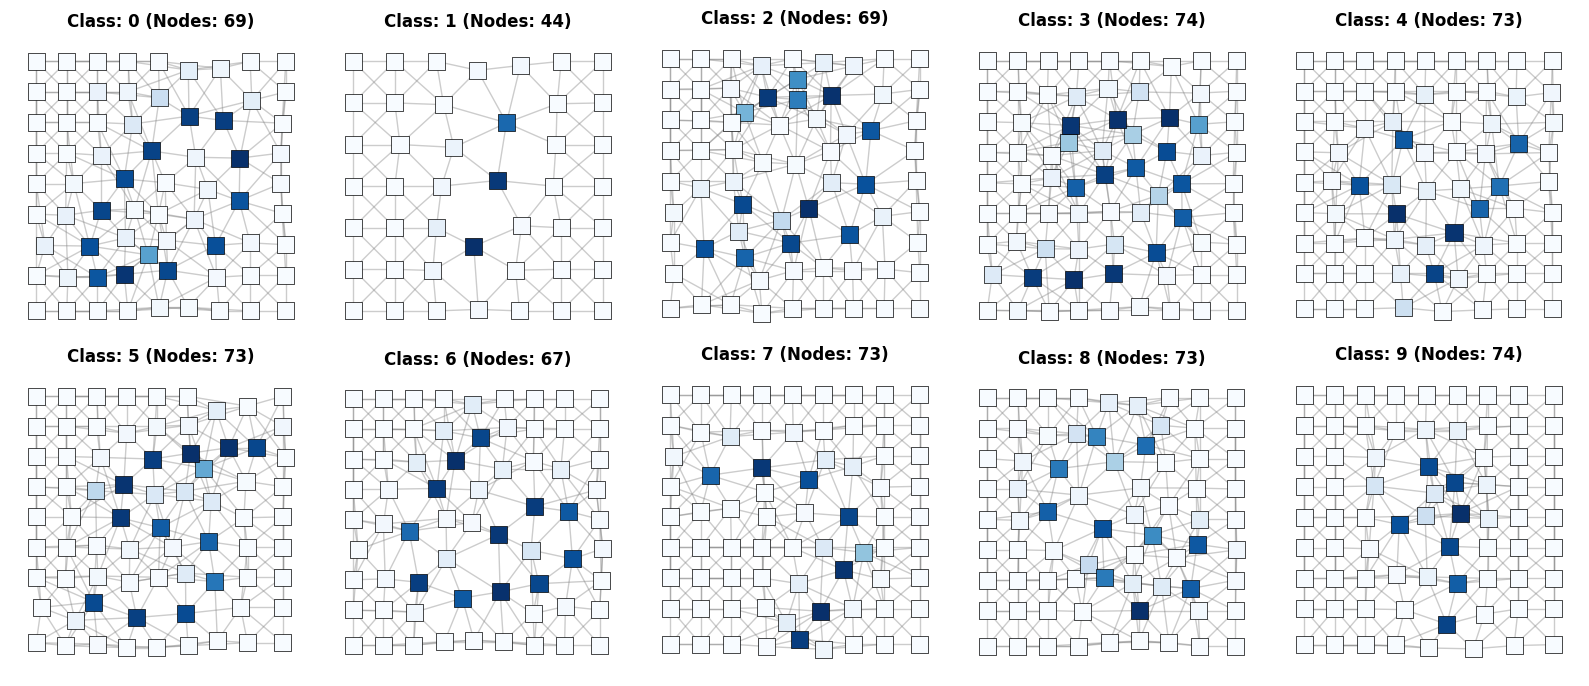

In [58]:
import matplotlib.pyplot as plt
import networkx as nx
from torch_geometric.utils import to_networkx

class_samples = {}

# Safely collect one sample per class
for i in range(len(train_dataset)):
    data = train_dataset[i]
    label = int(data.y.item())
    if label not in class_samples:
        class_samples[label] = data
    if len(class_samples) == 10:
        break

print("Visualizing one sample from each class in the training dataset:")

fig, axes = plt.subplots(2, 5, figsize=(16, 7))
axes = axes.flatten()

for class_idx, ax in zip(sorted(class_samples.keys()), axes):
    data = class_samples[class_idx]
    
    # Convert to networkx
    G = to_networkx(data, to_undirected=True)
    
    # Extract positions for NetworkX edges
    pos_dict = {j: data.pos[j].numpy() for j in range(data.num_nodes)}
    
    # 1. Draw the edges safely
    nx.draw_networkx_edges(G, pos_dict, ax=ax, edge_color='gray', alpha=0.4)
    
    # 2. Draw the nodes using matplotlib's scatter (Much more reliable)
    # Feature 0 is the pixel intensity based on our conversion script
    intensities = data.x[:, 0].numpy() 
    x_coords = data.pos[:, 0].numpy()
    y_coords = data.pos[:, 1].numpy()
    
    ax.scatter(
        x_coords, 
        y_coords, 
        c=intensities, 
        cmap='Blues', 
        marker='s',       # Square markers
        s=150,            # Size of the superpixels
        edgecolor='black',
        linewidth=0.5,
        zorder=5          # Ensures nodes are drawn on top of edges
    )
    
    # Format the plot
    ax.invert_yaxis()
    ax.set_aspect('equal') # Keeps the aspect ratio square
    ax.set_title(f"Class: {class_idx} (Nodes: {data.num_nodes})", fontweight='bold')
    ax.axis('off')

# Turn off any unused axes if there are fewer than 10 classes
for ax in axes[len(class_samples):]:
    ax.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx
from torch_geometric.utils import to_networkx

sample_idx = 0
data = train_dataset[sample_idx]

pos = data.pos.cpu().numpy()
intensity = data.x[:, 0].cpu().numpy() if data.x.dim() > 1 else data.x.cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(
    pos[:, 0],
    pos[:, 1],
    c=intensity,
    cmap='gray_r',
    s=45,
    edgecolors='none'
 )
axes[0].invert_yaxis()
axes[0].set_title('Node positions colored by intensity')
axes[0].set_aspect('equal')

graph = to_networkx(data, to_undirected=True)
pos_dict = {i: pos[i] for i in range(data.num_nodes)}
nx.draw_networkx_edges(graph, pos_dict, ax=axes[1], edge_color='lightgray', alpha=0.6, width=0.7)
scatter = axes[1].scatter(
    pos[:, 0],
    pos[:, 1],
    c=intensity,
    cmap='gray_r',
    s=45,
    edgecolors='black',
    linewidths=0.2
 )
axes[1].invert_yaxis()
axes[1].set_title('Same sample with graph edges')
axes[1].set_aspect('equal')

fig.colorbar(scatter, ax=axes, shrink=0.85, label='Node intensity')
plt.tight_layout()
plt.show()

print(f'Label: {int(data.y.item())}')
print(f'Nodes: {data.num_nodes}, Edges: {data.edge_index.size(1)}')

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx

print("Plotting the graphs (Image-style)...")
fig, axes = plt.subplots(2, 5, figsize=(16, 7))

for class_idx, ax in zip(sorted(class_samples.keys()), axes.flatten()):
    graph_data = class_samples[class_idx]
    
    # 1. Get coordinates and pixel intensities
    x_coords = graph_data.pos[:, 0].numpy()
    y_coords = graph_data.pos[:, 1].numpy()
    
    # The first feature column in data.x is the pixel intensity
    intensities = graph_data.x[:, 0].numpy() 
    

    ax.scatter(x_coords, y_coords, 
               c=intensities, cmap='Blues',  # Use 'gray' or 'Blues'
               marker='s', s=250)            # 's' specifies a square marker
    

    import torch
    row, col = graph_data.edge_index
    for i in range(graph_data.num_edges):
        start = graph_data.pos[row[i]].numpy()
        end = graph_data.pos[col[i]].numpy()
        ax.plot([start[0], end[0]], [start[1], end[1]], color='black', alpha=0.1, linewidth=1)
    
    # Format the plot
    ax.invert_yaxis() # Keep digits upright
    ax.set_aspect('equal') # Keep the proportions square
    ax.axis('off') # Hide the grid and axes for a clean image look
    ax.set_title(f"Class: {class_idx}", fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt

def plot_graph_and_mask(graph_data):
    """Plots a sparsified superpixel graph with its ground-truth node mask."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

    x_coords = graph_data.pos[:, 0].numpy()
    y_coords = graph_data.pos[:, 1].numpy()
    row, col = graph_data.edge_index

    intensities = graph_data.x[:, 0].numpy()
    for i in range(graph_data.num_edges):
        start = graph_data.pos[row[i]].numpy()
        end = graph_data.pos[col[i]].numpy()
        ax1.plot([start[0], end[0]], [start[1], end[1]], color='gray', alpha=0.3, linewidth=1)

    ax1.scatter(
        x_coords, y_coords, c=intensities, cmap='Blues',
        marker='s', s=300, edgecolor='black', linewidth=0.5
    )
    ax1.invert_yaxis()
    ax1.set_aspect('equal')
    ax1.axis('off')
    ax1.set_title(f"Original Graph (Digit: {graph_data.y.item()})", fontweight='bold')

    gt_mask = graph_data.node_mask.numpy()
    for i in range(graph_data.num_edges):
        start = graph_data.pos[row[i]].numpy()
        end = graph_data.pos[col[i]].numpy()
        ax2.plot([start[0], end[0]], [start[1], end[1]], color='gray', alpha=0.3, linewidth=1)

    cmap_binary = plt.cm.colors.ListedColormap(['#e0e0e0', '#2ca02c'])
    ax2.scatter(
        x_coords, y_coords, c=gt_mask, cmap=cmap_binary,
        marker='s', s=300, edgecolor='black', linewidth=0.5
    )
    ax2.invert_yaxis()
    ax2.set_aspect('equal')
    ax2.axis('off')
    ax2.set_title("Ground Truth Explanation Mask", fontweight='bold')

    plt.tight_layout()
    plt.show()

# Reuse already loaded/sparsified data (no new dataset download)
sample_graph = train_dataset[0]
plot_graph_and_mask(sample_graph)

In [45]:
from pathlib import Path

def _materialize_split(split_dataset):
    return [split_dataset[i].clone() for i in range(len(split_dataset))]

export_dir = Path("data/MNIST/sparsified_pt_splits")
export_dir.mkdir(parents=True, exist_ok=True)

train_pt = export_dir / "train_sparsified.pt"
val_pt = export_dir / "val_sparsified.pt"
test_pt = export_dir / "test_sparsified.pt"
meta_pt = export_dir / "split_metadata.pt"

train_graphs = _materialize_split(train_dataset)
torch.save(train_graphs, train_pt)
del train_graphs

val_graphs = _materialize_split(val_dataset)
torch.save(val_graphs, val_pt)
del val_graphs

test_graphs = _materialize_split(balanced_test_dataset)
torch.save(test_graphs, test_pt)
del test_graphs

metadata = {
    "source": "MNISTSuperpixels",
    "sparsification": {
        "threshold": 0.1,
        "distance_space": "per-graph min-max normalized coordinates",
        "gaussian_noise": None
    },
    "split": {
        "train_size": len(train_dataset),
        "val_size": len(val_dataset),
        "test_size": len(balanced_test_dataset),
        "train_indices": list(train_indices),
        "val_indices": list(val_indices),
        "test_indices": list(balanced_test_indices),
        "train_val_source_size": len(train_val_dataset),
        "split_seed": 42
    },
    "files": {
        "train": str(train_pt),
        "val": str(val_pt),
        "test": str(test_pt)
    }
}
torch.save(metadata, meta_pt)

reloaded_train = torch.load(train_pt, map_location="cpu", weights_only=False)
reloaded_val = torch.load(val_pt, map_location="cpu", weights_only=False)
reloaded_test = torch.load(test_pt, map_location="cpu", weights_only=False)
reloaded_meta = torch.load(meta_pt, map_location="cpu", weights_only=False)

assert len(reloaded_train) == len(train_dataset), "Train .pt size mismatch."
assert len(reloaded_val) == len(val_dataset), "Val .pt size mismatch."
assert len(reloaded_test) == len(balanced_test_dataset), "Test .pt size mismatch."
assert reloaded_meta["sparsification"]["gaussian_noise"] is None, "Gaussian noise flag should be None."

print("Saved sparsified dataset splits successfully:")
print(f"- {train_pt}")
print(f"- {val_pt}")
print(f"- {test_pt}")
print(f"- {meta_pt}")
print("Reload checks passed. Splits are reusable in other code.")

Saved sparsified dataset splits successfully:
- data/MNIST/sparsified_pt_splits/train_sparsified.pt
- data/MNIST/sparsified_pt_splits/val_sparsified.pt
- data/MNIST/sparsified_pt_splits/test_sparsified.pt
- data/MNIST/sparsified_pt_splits/split_metadata.pt
Reload checks passed. Splits are reusable in other code.


In [46]:
len(reloaded_train), len(reloaded_val), len(reloaded_test)

(20000, 5000, 1000)

In [ ]:
import torch
sample = torch.load("data/MNIST/sparsified_pt_splits/train_sparsified.pt", weights_only=False)[0]
print(hasattr(sample, "node_mask"), sample.node_mask.shape if hasattr(sample, "node_mask") else None)

In [16]:
# Load just the first graph from your saved dataset
sample = torch.load("data/MNIST/sparsified_pt_splits/train_sparsified.pt", weights_only=False)[0]

print("=== GRAPH TOPOLOGY ===")
print(f"Number of nodes: {sample.num_nodes}")
print(f"Number of edges: {sample.num_edges}")

print("\n=== NODE FEATURES (x) ===")
print(f"Shape: {sample.x.shape} -> (num_nodes, num_features)")
print("First 5 nodes' features:")
print(sample.x[:5])

print("\n=== GROUND TRUTH MASK ===")
print(f"Shape: {sample.node_mask.shape}")
print(f"Number of 'important' nodes: {int(sample.node_mask.sum().item())}")

if getattr(sample, 'pos', None) is not None:
    print("\n=== POSITIONS (pos) ===")
    print(f"Shape: {sample.pos.shape}")
    print("First 5 nodes' positions:")
    print(sample.pos[:5])
else:
    print("\nNo explicit 'pos' attribute found.")

=== GRAPH TOPOLOGY ===
Number of nodes: 73
Number of edges: 73

=== NODE FEATURES (x) ===
Shape: torch.Size([73, 1]) -> (num_nodes, num_features)
First 5 nodes' features:
tensor([[0.0248],
        [0.9417],
        [0.8210],
        [0.0000],
        [0.0000]])

=== GROUND TRUTH MASK ===
Shape: torch.Size([73])
Number of 'important' nodes: 31

No explicit 'pos' attribute found.


Visualizing one sample from each class in the training dataset:


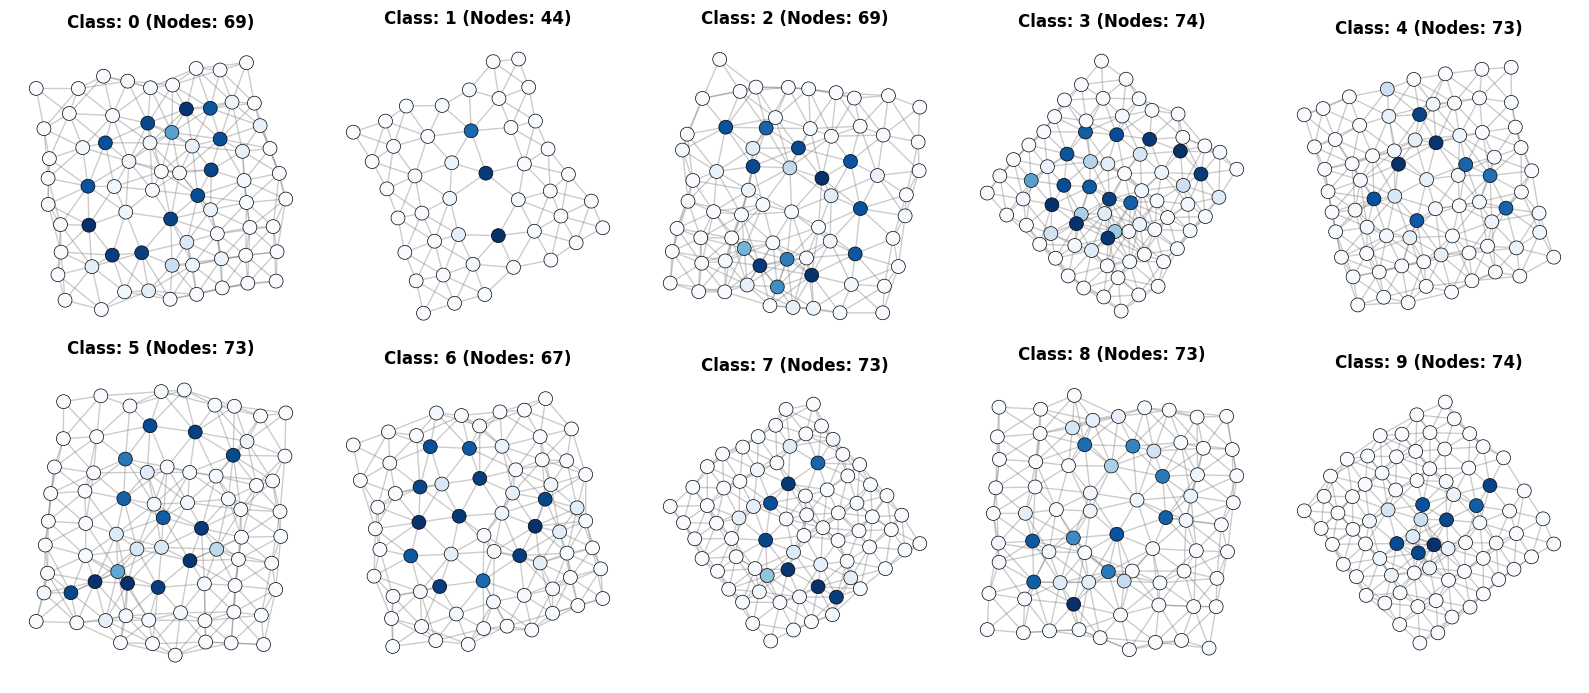

In [59]:
import matplotlib.pyplot as plt
import networkx as nx
from torch_geometric.utils import to_networkx

class_samples = {}

# Safely collect one sample per class
for i in range(len(train_dataset)):
    data = train_dataset[i]
    label = int(data.y.item())
    if label not in class_samples:
        class_samples[label] = data
    if len(class_samples) == 10:
        break

print("Visualizing one sample from each class in the training dataset:")

fig, axes = plt.subplots(2, 5, figsize=(16, 7))
axes = axes.flatten()

for class_idx, ax in zip(sorted(class_samples.keys()), axes):
    data = class_samples[class_idx]
    
    # Convert to networkx
    G = to_networkx(data, to_undirected=True)
    
    # 1. Dynamically compute spatial layout (since spatial coords were stripped)
    pos_dict = nx.kamada_kawai_layout(G)
    x_coords = [pos_dict[j][0] for j in range(data.num_nodes)]
    y_coords = [pos_dict[j][1] for j in range(data.num_nodes)]
        
    # 2. Extract Intensities (We know data.x has shape [num_nodes, 1])
    intensities = data.x[:, 0].numpy()
        
    # 3. Draw the edges
    nx.draw_networkx_edges(G, pos_dict, ax=ax, edge_color='gray', alpha=0.4)
    
    # 4. Draw nodes using matplotlib's scatter
    ax.scatter(
        x_coords, 
        y_coords, 
        c=intensities, 
        cmap='Blues', 
        marker='o',       # Circles look better for network layouts
        s=100,            # Node size
        edgecolor='black',
        linewidth=0.5,
        zorder=5          # Ensures nodes are drawn on top of edges
    )
    
    # Format the plot
    ax.set_aspect('equal')
    ax.set_title(f"Class: {class_idx} (Nodes: {data.num_nodes})", fontweight='bold')
    ax.axis('off')

# Turn off any unused axes
for ax in axes[len(class_samples):]:
    ax.axis('off')

plt.tight_layout()
plt.show()

Visualizing Ground Truth Masks for MNIST Superpixels:


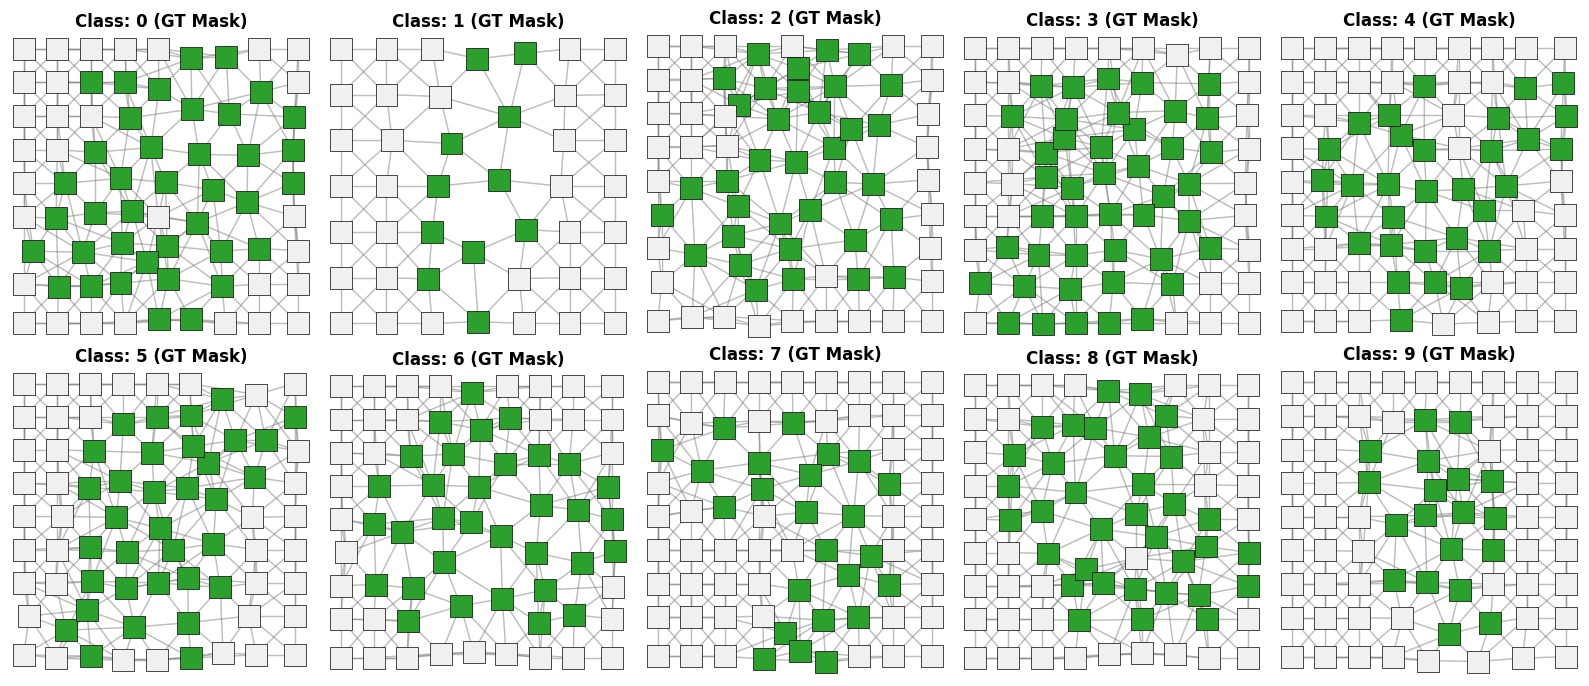

In [60]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import networkx as nx

class_samples = {}
for i in range(len(train_dataset)):
    data = train_dataset[i]
    label = int(data.y.item())
    if label not in class_samples:
        class_samples[label] = data
    if len(class_samples) == 10:
        break

print("Visualizing Ground Truth Masks for MNIST Superpixels:")
fig, axes = plt.subplots(2, 5, figsize=(16, 7))

# Create a custom binary colormap: light gray for background (0), bright green for truth (1)
cmap_binary = mcolors.ListedColormap(['#f0f0f0', '#2ca02c'])

for class_idx, ax in zip(sorted(class_samples.keys()), axes.flatten()):
    graph_data = class_samples[class_idx]
    
    x_coords = graph_data.pos[:, 0].numpy()
    y_coords = graph_data.pos[:, 1].numpy()
    
    # Extract the Ground Truth Mask instead of intensities
    mask_values = graph_data.node_mask.numpy() 
    
    # Draw edges
    row, col = graph_data.edge_index
    for i in range(graph_data.num_edges):
        start = graph_data.pos[row[i]].numpy()
        end = graph_data.pos[col[i]].numpy()
        ax.plot([start[0], end[0]], [start[1], end[1]], color='gray', alpha=0.3, linewidth=1, zorder=1)
        
    # Draw nodes colored by the binary mask
    ax.scatter(
        x_coords, y_coords, 
        c=mask_values, cmap=cmap_binary, 
        marker='s', s=250, edgecolor='black', linewidth=0.5, zorder=5
    )
    
    ax.invert_yaxis() # Keep digits upright
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(f"Class: {class_idx} (GT Mask)", fontweight='bold')

plt.tight_layout()
plt.show()

Visualizing Original Intensities + Ground Truth Masks (Overlaid):
-> Fill Color: Original Pixel Intensity (Blues)
-> Thick Green Border: Ground Truth Mask == 1


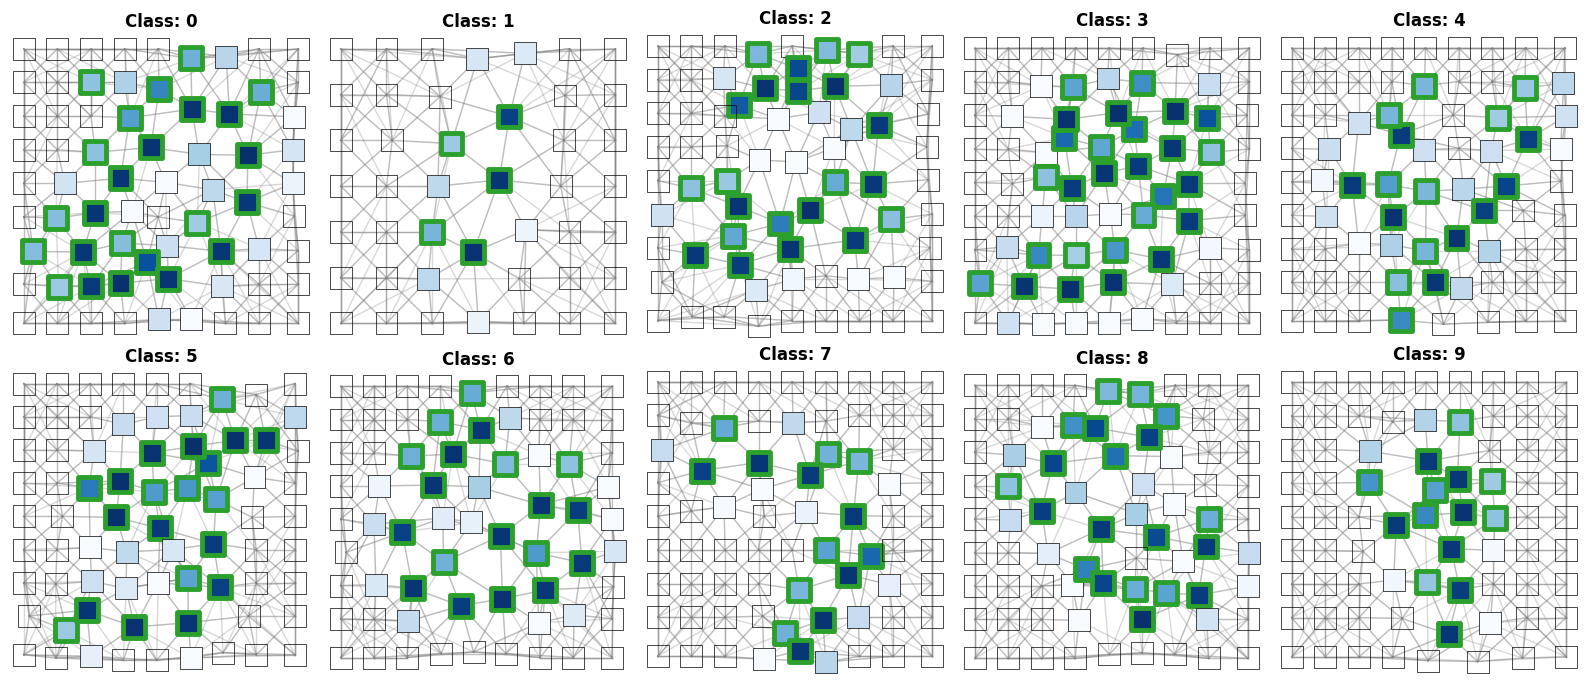

In [35]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as colors


class_samples = {}
for i in range(len(train_dataset)):
    data = train_dataset[i]
    label = int(data.y.item())
    if label not in class_samples:
        class_samples[label] = data
    if len(class_samples) == 10:
        break

print("Visualizing Original Intensities + Ground Truth Masks (Overlaid):")
print("-> Fill Color: Original Pixel Intensity (Blues)")
print("-> Thick Green Border: Ground Truth Mask == 1")

fig, axes = plt.subplots(2, 5, figsize=(16, 7))

for class_idx, ax in zip(sorted(class_samples.keys()), axes.flatten()):
    graph_data = class_samples[class_idx]
    
    x_coords = graph_data.pos[:, 0].numpy()
    y_coords = graph_data.pos[:, 1].numpy()
    
    intensities = graph_data.x[:, 0].numpy()
    mask_values = graph_data.node_mask.numpy()
    
    # Draw edges
    row, col = graph_data.edge_index
    for i in range(graph_data.num_edges):
        start = graph_data.pos[row[i]].numpy()
        end = graph_data.pos[col[i]].numpy()
        ax.plot([start[0], end[0]], [start[1], end[1]], color='gray', alpha=0.3, linewidth=1, zorder=1)
        
    # Determine border colors and thicknesses based on the ground truth mask
    # Green border if mask == 1.0, otherwise a thin black border
    border_colors = np.where(mask_values == 1.0, '#2ca02c', 'black')
    border_widths = np.where(mask_values == 1.0, 3.5, 0.5)

    # Draw nodes
    ax.scatter(
        x_coords, y_coords, 
        c=intensities, 
        cmap='Blues', 
        norm = colors.LogNorm(vmin=0.01, vmax=1.0),  # Log scale for better contrast
        marker='s', s=250, 
        edgecolors=border_colors, linewidths=border_widths, zorder=5
    )
    
    ax.invert_yaxis() # Keep digits upright
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(f"Class: {class_idx}", fontweight='bold')

plt.tight_layout()
plt.show()